## Implementing a dummy binary-classifier with fit-predict interface

#### Qa  Load and display the MNIST data

The MNIST database consists of handwritten digits and has a training set of 60,000 examples. It’s retrieved from openml.org, and each digit in the dataset is a 28x28-pixel image.

The value of X[0] is: 5


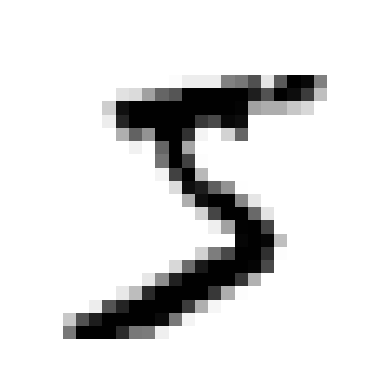

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784', return_X_y=True, as_frame=False)

def MNIST_PlotDigit(data):
    import matplotlib
    import matplotlib.pyplot as plt
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")
    plt.show()


X, y = MNIST_GetDataSet()
print(f'The value of X[0] is: {y[0]}')
MNIST_PlotDigit(X[0])

The return_X_y parameter makes fetch_openml return a tuple (data, target) instead of a Bunch container, which otherwise contains more information about the dataset.
Once the dataset is retrieved, a single digit can be displayed with the MNIST_PlotDigit(data) function.

From the output above, you can see that the value of X[0] is 5 and the plot shows the handwritten digit located in that position.

#### Qb  Add a Stochastic Gradient Decent [SGD] Classifier

The dataset is split into a training and a test part so that testing and training aren’t done on exactly the same data, and an SGD Classifier is used to train the model on the data in the training part. This implementation can be seen below:

In [27]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.linear_model import SGDClassifier

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

shuffle_idx = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)


SGDClassifier(random_state=42)

Next, a true positive (a correctly classified digit), a false positive (a digit the model thinks is a 5 but is actually something else), and finally a true negative (a number correctly not classified as 5) are identified. The implementation is shown below.

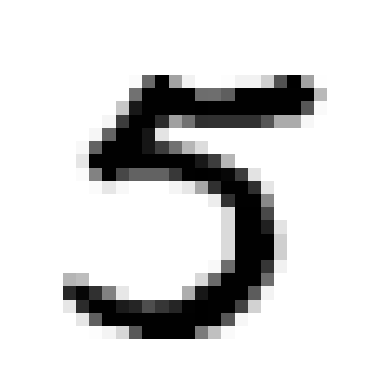

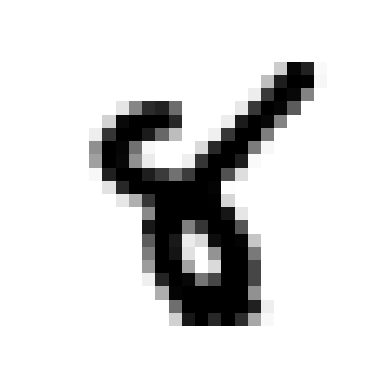

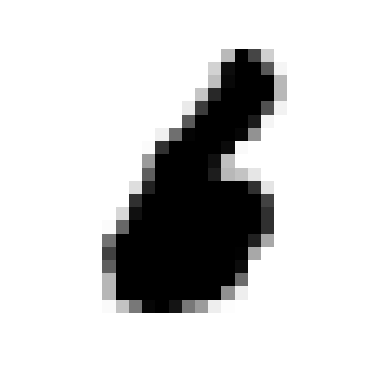

In [28]:
import numpy as np

# Predict labels
y_test_pred = sgd_clf.predict(X_test)

# Random true positive
true_pos_idx = np.where((y_test_5 == True) & (y_test_pred == True))[0]
rand_true_pos = np.random.choice(true_pos_idx)

# Random false positive
false_pos_idx = np.where((y_test_5 == False) & (y_test_pred == True))[0]
rand_false_pos = np.random.choice(false_pos_idx)

# Random true negative
true_neg_idx = np.where((y_test_5 == False) & (y_test_pred == False))[0]
rand_true_neg = np.random.choice(true_neg_idx)

# Plot a digit
MNIST_PlotDigit(X_test[rand_true_pos])
MNIST_PlotDigit(X_test[rand_false_pos])
MNIST_PlotDigit(X_test[rand_true_neg])


The first picture is the true positive, the second is the false positive and the final is the true negative. This clearly visualizes how the model performs and where it makes mistakes.

#### Qc Implement a dummy binary classifier

Below is the implementation of a dummy classifier, which consists of a fit and a predict method. The dummy classifier only returns zeros when the predict function is used.

In [29]:
from sklearn.base import BaseEstimator

class DummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X),), dtype=bool)

In [30]:
from sklearn.metrics import accuracy_score

dummy = DummyClassifier()

dummy.fit(X_train, y_train_5)
y_dummy_pred = dummy.predict(X_test)
print(f"{y_dummy_pred}")

dummy_accuracy = accuracy_score(y_test_5, y_dummy_pred)
print(f"score for DummyClassifier: {dummy_accuracy:.2%}")

[False False False ... False False False]
score for DummyClassifier: 91.08%


### Qd Conclusion

The exercise provides a good understanding of how an estimator is used and how you can create your own classifier using BaseEstimator from the scikit-learn library. It also showed that it’s possible to create an estimator that doesn’t actually work (DummyClassifier) but still produces good results. It’s also very important to split your dataset so you don’t end up training and testing on the same chunk of data.

REVISIONS||
:- | :- |
2018-12-19| CEF, initial.
2018-02-06| CEF, updated and spell checked.
2018-02-08| CEF, minor text update.
2018-03-05| CEF, updated with SHN comments.
2019-09-02| CEF, updated for ITMAL v2.
2019-09-04| CEF, updated and added conclusion Q.
2020-01-25| CEF, F20 ITMAL update.
2020-02-04| CEF, updated page numbers to HOMLv2.
2020-09-03| CEF, E20 ITMAL update, udpated figs paths.
2020-09-06| CEF, added alt text.
2020-09-18| CEF, added binary-classifier text to Qb to emphasise 5/non-5 classification.
2021-01-12| CEF, F21 ITMAL update, moved revision tabel.
2021-08-02| CEF, update to E21 ITMAL.
2022-01-25| CEF, update to F22 SWMAL.
2023-02-07| CEF, update HOML page numbers.
2024-02-14| CEF, added note on sklearn.dummy.DummyClassifier.
2024-09-13| CEF, updated p.107 and editions text references.